In [1]:
import pandas as pd 
import numpy as np 
import yfinance as yf 
from scipy.optimize import minimize
import matplotlib.pyplot as plt 
from datetime import datetime 
import seaborn as sns

pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x) 

<span style="font-size:18px; color:Black;"> **Dowload Data** </span>

In [2]:
tickers = {
    'US_10Yr_Treasury': 'IEF',  # iShares 7-10 Year Treasury Bond ETF
    'US_REITs': 'IYR',          # iShares U.S. Real Estate ETF
    'US_Equities': '^GSPC',       # S&P 500 Index
    'US_Commodities':'^SPGSCI'  # S&P GSCI Index
}
start_date='2000-01-01'
end_date = '2026-04-01'
data = yf.download(list(tickers.values()), start=start_date, end=end_date, interval='1mo', auto_adjust=True)
prices = data['Close']
display(prices.head())

# find the first row with all non-NA values
first_valid_index = prices.dropna().index[0]
# filter the DataFrame to include only rows from the first valid index onward
prices = prices.loc[first_valid_index:]
# Calculate monthly returns
returns = prices.pct_change().fillna(0)
display(returns.head())
returns.to_csv('monthly_returns_26.csv')

[*********************100%***********************]  4 of 4 completed


Ticker,IEF,IYR,^GSPC,^SPGSCI
Date,,,,
2000-01-01,NaN,NaN,1394.4600,206.3700
2000-02-01,NaN,NaN,1366.4200,216.0100
2000-03-01,NaN,NaN,1498.5800,206.8800
2000-04-01,NaN,NaN,1452.4301,203.2100
2000-05-01,NaN,NaN,1420.6000,223.2000


Ticker,IEF,IYR,^GSPC,^SPGSCI
Date,,,,
2002-07-01,0.0000,0.0000,0.0000,0.0000
2002-08-01,0.0252,0.0036,0.0049,0.0582
2002-09-01,0.0350,-0.0628,-0.1100,0.0571
2002-10-01,-0.0120,-0.0266,0.0864,-0.0444
2002-11-01,-0.0214,0.0484,0.0571,0.0004


In [3]:
tickers = {
    'US_10Yr_Treasury': 'IEF',  # iShares 7-10 Year Treasury Bond ETF
    'US_REITs': 'IYR',          # iShares U.S. Real Estate ETF
    'US_Equities': '^GSPC',       # S&P 500 Index
    'US_Commodities':'^SPGSCI'  # S&P GSCI Index
}

returns = pd.read_csv("monthly_returns_26.csv", index_col=0, parse_dates=True)
returns.index = pd.to_datetime(returns.index)
    
display(returns.head())

,IEF,IYR,^GSPC,^SPGSCI
Date,,,,
2002-07-01,0.0000,0.0000,0.0000,0.0000
2002-08-01,0.0252,0.0036,0.0049,0.0582
2002-09-01,0.0350,-0.0628,-0.1100,0.0571
2002-10-01,-0.0120,-0.0266,0.0864,-0.0444
2002-11-01,-0.0214,0.0484,0.0571,0.0004


In [4]:
display(returns.tail())

,IEF,IYR,^GSPC,^SPGSCI
Date,,,,
2025-11-01,0.0098,0.0237,0.0013,-0.0033
2025-12-01,-0.0106,-0.0311,-0.0005,-0.0120
2026-01-01,0.0039,0.0341,0.0137,0.0906
2026-02-01,0.0214,0.0527,-0.0087,0.0212
2026-03-01,-0.0228,-0.0664,-0.0509,0.2198


<span style="font-size:18px; color:Black;"> **Optimization for max return, min volalitility, max sharpe ratio portfolios** </span> 

In [5]:
#use historial mean and covariance
annualized_returns = returns.mean().values * 12
annualized_covariance = returns.cov().values * 12 #default is 1/(n-1)
annualized_volatility = returns.std().values * np.sqrt(12)

display(annualized_returns)
display(annualized_covariance)
display(annualized_volatility)

array([0.03737454, 0.09529655, 0.0940333 , 0.0809951 ])

array([[ 0.00445808,  0.00167651, -0.00100104, -0.00371778],
       [ 0.00167651,  0.04338295,  0.02223862,  0.00984407],
       [-0.00100104,  0.02223862,  0.02151434,  0.0115074 ],
       [-0.00371778,  0.00984407,  0.0115074 ,  0.05115568]])

array([0.06676882, 0.20828573, 0.14667768, 0.22617622])

In [6]:
# helper function
def portfolio_return(weights,mu):
    return weights @ mu
def portfolio_volatility(weights, sigma):
    return np.sqrt(weights @ sigma @ weights)
def sharpe_ratio(weights, mu, cov, rf=0): # rf=0 cost of financing is not taken into account
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return (ret-rf) / vol

In [7]:
def run_opt(ptf_type, returns, covariance):
    w = np.array([0.25, 0.25, 0.25, 0.25]) # initial guess
    bounds = tuple((0, 1) for _ in range(len(w))) # no short constraints
    weight_constraint = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1} # weights sum to 1
    constraints = [weight_constraint]

    # type1: maximize return subject to annualized volatility < 10%
    if ptf_type == 'max_return':
        constraints.append({'type': 'ineq', 'fun': lambda x: 0.1 - portfolio_volatility(x, covariance)})
        obj = lambda x: -portfolio_return(x, returns) # negative for maximization
        res = minimize(obj, w, method='SLSQP', bounds=bounds, constraints=constraints)

        optimal_weights = res.x
        optimal_return = -res.fun
        optimal_vol = portfolio_volatility(optimal_weights, covariance)
        optimal_sharpe = sharpe_ratio(optimal_weights, returns, covariance)

    # type2: minimize volatility subject to annualized return > 4%
    if ptf_type == 'min_vol':
        constraints.append({'type': 'ineq', 'fun': lambda x: portfolio_return(x, returns) - 0.04})
        obj = lambda x: portfolio_volatility(x, covariance)
        res = minimize(obj, w, method='SLSQP', bounds=bounds, constraints=constraints)

        optimal_weights = res.x
        optimal_return = portfolio_return(optimal_weights, returns)
        optimal_vol = res.fun
        optimal_sharpe = sharpe_ratio(optimal_weights, returns, covariance)
    
    # type3: maximize sharpe ratio
    if ptf_type == 'max_sharpe':
        obj = lambda x: -sharpe_ratio(x, returns, covariance) # negative for maximization
        res = minimize(obj, w, method='SLSQP', bounds=bounds, constraints=constraints)

        optimal_weights = res.x
        optimal_return = portfolio_return(optimal_weights, returns)
        optimal_vol = portfolio_volatility(optimal_weights, covariance)
        optimal_sharpe = -res.fun

    return optimal_weights, optimal_return, optimal_vol, optimal_sharpe
    


In [8]:
asset_names = list(tickers.keys())

def print_portfolio(returns, covariance, asset_names):
    w1, ret1, vol1, sr1 = run_opt('max_return', returns, covariance)
    w2, ret2, vol2, sr2 = run_opt('min_vol', returns, covariance)
    w3, ret3, vol3, sr3 = run_opt('max_sharpe', returns, covariance)

    weights_data = {
    'Max Return (Vol < 10%)': np.around(w1*100, 4),
    'Min Volatility (Return > 4%)': np.around(w2*100, 4),
    'Max Sharpe Ratio': np.around(w3*100, 4)
    }
    df_weights = pd.DataFrame(weights_data, index=asset_names)

    perf_data = {
    'Max Return (Vol < 10%)': [np.around(ret1*100, 4), np.around(vol1*100, 4), sr1],
    'Min Volatility (Return > 4%)': [np.around(ret2*100, 4), np.around(vol2*100, 4), sr2],
    'Max Sharpe Ratio': [np.around(ret3*100, 4), np.around(vol3*100, 4), sr3]
    }

    df_perf = pd.DataFrame(perf_data, index=['Expected Annualized Return (%)', 'Expected Annualized Volatility (%)', 'Expected Sharpe Ratio'])

    df_final = pd.concat([df_weights, df_perf], axis=0)
    print(df_final)


print_portfolio(annualized_returns, annualized_covariance, asset_names)

                                    Max Return (Vol < 10%)  Min Volatility (Return > 4%)  Max Sharpe Ratio
US_10Yr_Treasury                                   28.1078                       78.2254           65.5181
US_REITs                                            0.0000                        0.0000            0.0000
US_Equities                                        62.3416                       13.1000           25.5870
US_Commodities                                      9.5506                        8.6746            8.8949
Expected Annualized Return (%)                      7.6863                        4.8581            5.5752
Expected Annualized Volatility (%)                 10.0001                        5.5081            5.9007
Expected Sharpe Ratio                               0.7686                        0.8820            0.9448


<span style="font-size:18px; color:Black;"> **Optimization under equal sharpe ratio assumption** </span>  

In [9]:
def set_average_sharpe_ratio(returns, covariance):
    # Adjusts asset returns so all assets have the same Sharpe ratio
    # using the average Sharpe ratio of the original assets
    volatilities = np.sqrt(np.diag(covariance))
    original_sharpe_ratios = returns / volatilities
    avg_sharpe = np.mean(original_sharpe_ratios)
    print(f"Average Sharpe Ratio of assets: {avg_sharpe:.4f}")
    
    adjusted_returns = avg_sharpe * volatilities
    return adjusted_returns

avg_sharpe_returns = set_average_sharpe_ratio(annualized_returns, annualized_covariance)
print("\nComparison of Original vs. Adjusted Returns:")
comparison_df = pd.DataFrame({
    'Original Returns': annualized_returns,
    'Adjusted Returns': avg_sharpe_returns,
    'Volatility': np.sqrt(np.diag(annualized_covariance)),
    'Original Sharpe': annualized_returns / np.sqrt(np.diag(annualized_covariance)),
    'New Sharpe': avg_sharpe_returns / np.sqrt(np.diag(annualized_covariance))
}, index=asset_names)
print(comparison_df.round(4))

Average Sharpe Ratio of assets: 0.5041

Comparison of Original vs. Adjusted Returns:
                  Original Returns  Adjusted Returns  Volatility  Original Sharpe  New Sharpe
US_10Yr_Treasury            0.0374            0.0337      0.0668           0.5598      0.5041
US_REITs                    0.0953            0.1050      0.2083           0.4575      0.5041
US_Equities                 0.0940            0.0739      0.1467           0.6411      0.5041
US_Commodities              0.0810            0.1140      0.2262           0.3581      0.5041


In [10]:
print('Optimization Results assuming equal Sharpe ratios (Average sharpe ratio):\n')
print_portfolio(avg_sharpe_returns, annualized_covariance, asset_names)

Optimization Results assuming equal Sharpe ratios (Average sharpe ratio):

                                    Max Return (Vol < 10%)  Min Volatility (Return > 4%)  Max Sharpe Ratio
US_10Yr_Treasury                                   41.6421                       78.2254           66.5395
US_REITs                                           26.5647                        0.0000            2.1486
US_Equities                                         0.3377                       13.1000           15.4207
US_Commodities                                     31.4555                        8.6746           15.8913
Expected Annualized Return (%)                      7.8025                        4.5908            5.4175
Expected Annualized Volatility (%)                 10.0000                        5.5081            6.0267
Expected Sharpe Ratio                               0.7803                        0.8335            0.8989


In [11]:
def plot_portfolio_weights(weights_data, asset_names, sharpe_ratios):
    weights_df = pd.DataFrame(weights_data, columns=asset_names, index=sharpe_ratios) # one row per optimization result
    plt.figure(figsize=(10, 6))
    for asset in asset_names:
        plt.plot(weights_df.index, weights_df[asset], label=asset) #x=sharpe ratio, y=weight
    plt.xlabel('Assumed Sharpe Ratio')
    plt.ylabel('Portfolio Weight')
    plt.title('Portfolio Weights vs. Assumed Sharpe Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()

Portfolio weights for Maximum return optimization across varying assumed Sharpe ratio


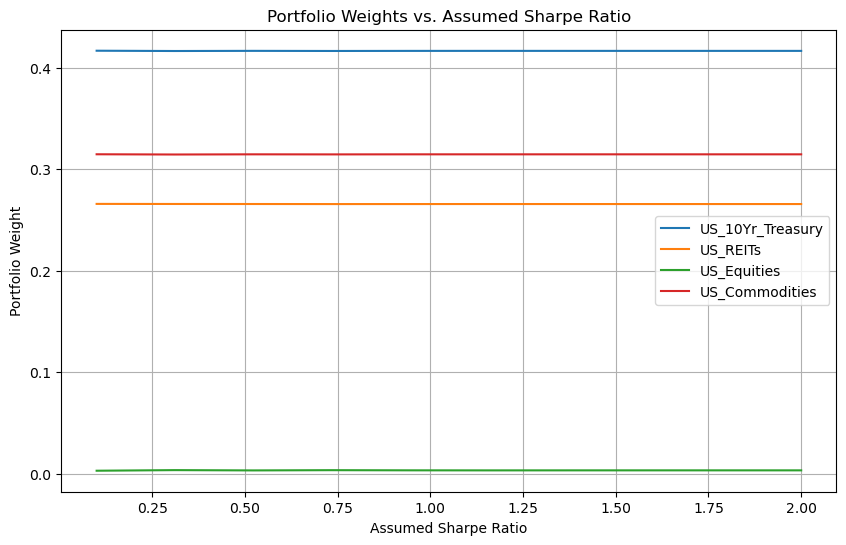

Portfolio weights for Maximum Sharpe ratio optimization across varying assumed Sharpe ratio


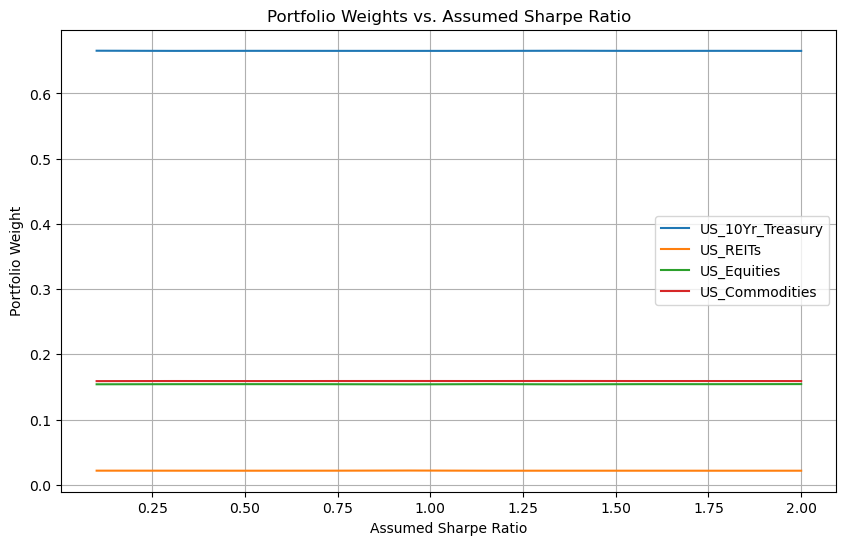

Portfolio weights for Minimum volatility optimization across varying assumed Sharpe ratio


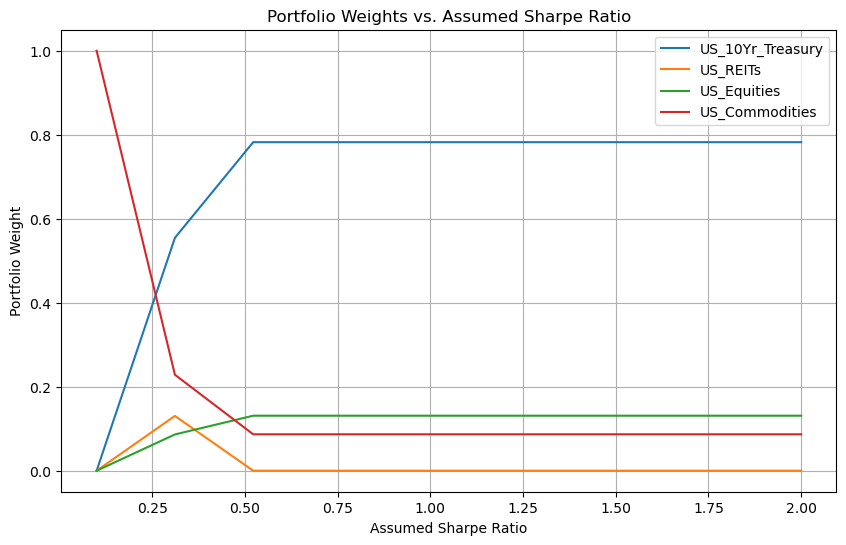

In [12]:
def run_sharpe_opt(sharpe_ratios, returns, covariance):
    weights_data_1 = []
    weights_data_2 = []
    weights_data_3 = []
    for sr in sharpe_ratios:
        adjusted_returns = sr * np.sqrt(np.diag(covariance)) 
        w, _, _, _ = run_opt('max_return', adjusted_returns, covariance)
        weights_data_1.append(w)
        w, _, _, _ = run_opt('max_sharpe', adjusted_returns, covariance)
        weights_data_2.append(w)
        w, _, _, _ = run_opt('min_vol', adjusted_returns, covariance)
        weights_data_3.append(w)
    
    print('Portfolio weights for Maximum return optimization across varying assumed Sharpe ratio')
    plot_portfolio_weights(weights_data_1, asset_names, sharpe_ratios)
    print('Portfolio weights for Maximum Sharpe ratio optimization across varying assumed Sharpe ratio')
    plot_portfolio_weights(weights_data_2, asset_names, sharpe_ratios)
    print('Portfolio weights for Minimum volatility optimization across varying assumed Sharpe ratio')
    plot_portfolio_weights(weights_data_3, asset_names, sharpe_ratios)
    
sharpe_ratios_test = np.linspace(0.1, 2, 10)
run_sharpe_opt(sharpe_ratios_test, annualized_returns, annualized_covariance)

<span style="font-size:18px; color:Black;"> **Is there any regime change for the risk assumption observed from the historical data? If yes, what is the impact on the portfolio optimization results?** </span> 

<Axes: title={'center': 'Rolling 12-Month Annualized Volatility'}, xlabel='Date', ylabel='Annualized Volatility'>

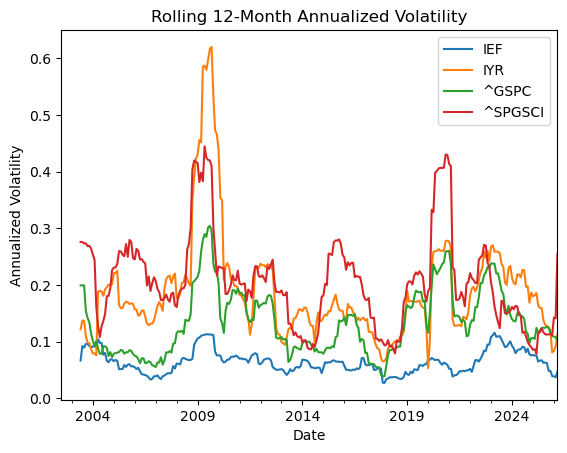

In [13]:
#calculate rolling 12-month standard deviation
rolling_volatility = returns.rolling(window=12).std() * np.sqrt(12)
rolling_volatility.plot(title='Rolling 12-Month Annualized Volatility', ylabel='Annualized Volatility', xlabel='Date')

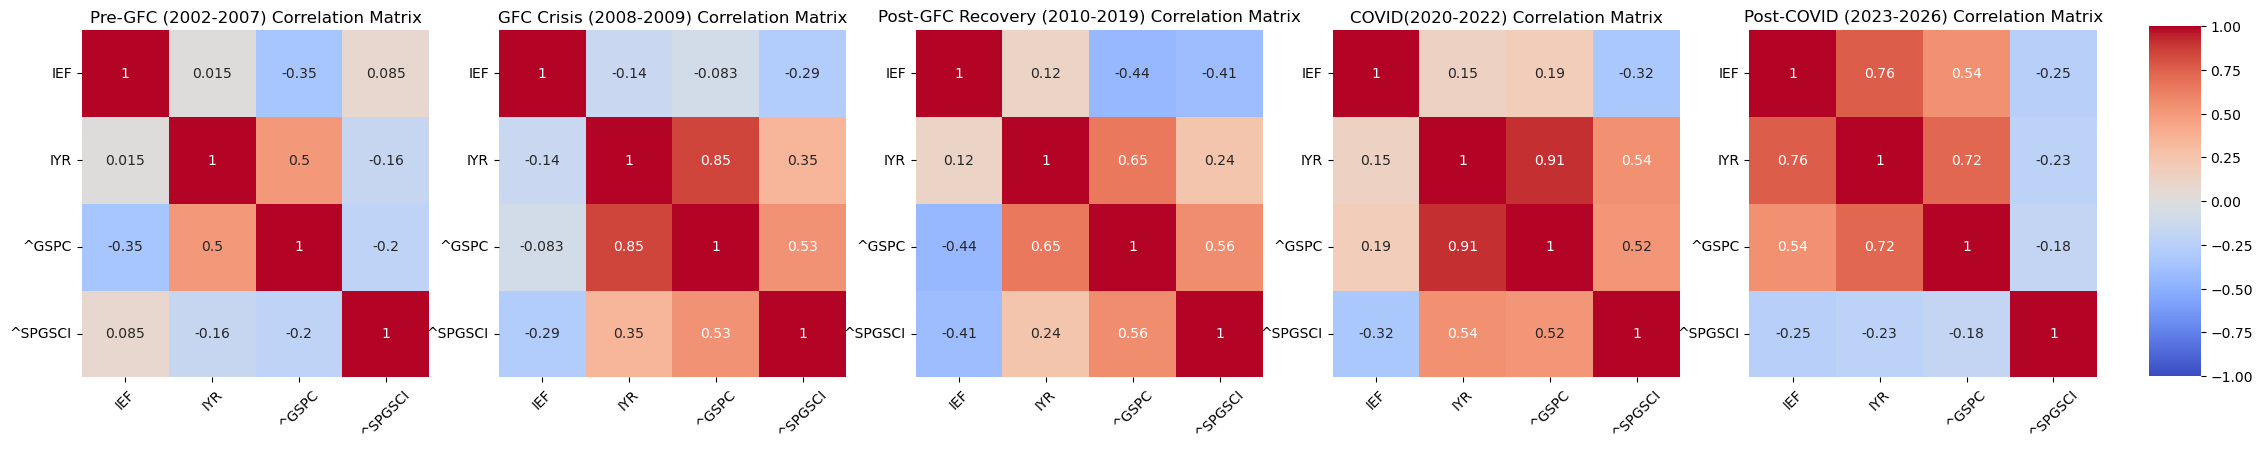

In [14]:
#define the regimes
regimes = {
    "Pre-GFC (2002-2007)": ("2002-08", "2007-12"),
    "GFC Crisis (2008-2009)": ("2008-01", "2009-12"),
    "Post-GFC Recovery (2010-2019)": ("2010-01", "2019-12"),
    "COVID(2020-2022)": ("2020-01", "2022-12"),
    "Post-COVID (2023-2026)": ("2023-01", "2026-03")
}

# Plot correlation matrices for each regime
def plot_correlation_by_regime(returns, regimes):
    n = len(regimes)
    fig, axes = plt.subplots(1, n, figsize=(5 * n + 1, 5))
    if n == 1:
        axes = [axes]
    # create a single colorbar axis on the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    for i, (regime_name, (start, end)) in enumerate(regimes.items()):
        regime_returns = returns.loc[start:end].dropna()
        corr = regime_returns.corr()
        show_cbar = (i == n - 1)
        sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                    ax=axes[i], cbar=show_cbar, cbar_ax=cbar_ax if show_cbar else None,
                    square=True)
        axes[i].set_title(f"{regime_name} Correlation Matrix")
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)
    plt.subplots_adjust(right=0.9)  # adjust spacing for colorbar
    plt.show()
plot_correlation_by_regime(returns, regimes)

In [15]:
# use ewma with lambda=0.94 to calculate volatility
lam = 0.94
def cal_ewma_series(returns, lam):
    returns_matrix = returns.values
    T, N = returns_matrix.shape

    # initialize with sample covariance of the first 12 months
    initial_period = 12
    ewma_cov_monthly = np.cov(returns_matrix[:initial_period].T)

    ewma_series = []
                        
    for t in range(initial_period, T):
        # update ewma covariance
        r = returns_matrix[t].reshape(-1, 1) # column vector
        ewma_cov_monthly = lam * ewma_cov_monthly + (1 - lam) * (r@r.T)
        ewma_series.append({"date": returns.index[t], \
                                "ewma_cov_annual": ewma_cov_monthly*12,\
                                "ewma_vol_annual": np.sqrt(np.diag(ewma_cov_monthly))*np.sqrt(12)})  

    return ewma_series
    
# get annualized volatility DataFrame
ewma_series = cal_ewma_series(returns, lam)
vol_array = np.vstack([entry['ewma_vol_annual'] for entry in ewma_series])  # shape: (len(series), N)
dates = [entry['date'] for entry in ewma_series]
ewma_vol_df = pd.DataFrame(vol_array, index=pd.to_datetime(dates), columns=returns.columns)
    
display(ewma_vol_df.head())
display(ewma_vol_df.tail())

,IEF,IYR,^GSPC,^SPGSCI
2003-07-01,0.0795,0.1320,0.1934,0.2672
2003-08-01,0.0772,0.1282,0.1881,0.2613
2003-09-01,0.0857,0.1250,0.1827,0.2557
2003-10-01,0.0839,0.1240,0.1831,0.2488
2003-11-01,0.0815,0.1258,0.1777,0.2426


,IEF,IYR,^GSPC,^SPGSCI
2025-11-01,0.0656,0.1556,0.1355,0.1290
2025-12-01,0.0642,0.1531,0.1314,0.1255
2026-01-01,0.0624,0.1513,0.1279,0.1439
2026-02-01,0.0631,0.1533,0.1242,0.1407
2026-03-01,0.0642,0.1590,0.1280,0.2311


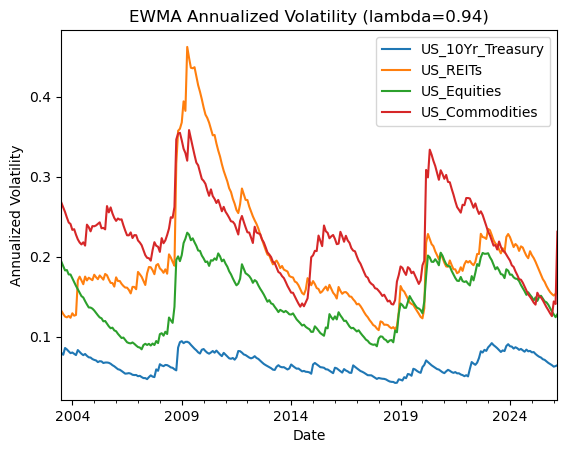

In [16]:
ax = ewma_vol_df.plot(title='EWMA Annualized Volatility (lambda=0.94)', ylabel='Annualized Volatility', xlabel='Date')
ax.legend(labels=list(tickers.keys()))
plt.show()


Optimization Results using EWMA covariance at the end of regime (Date: 2007-12-01):

                                    Max Return (Vol < 10%)  Min Volatility (Return > 4%)  Max Sharpe Ratio
US_10Yr_Treasury                                   21.3670                       65.9382           55.3410
US_REITs                                           26.3090                        0.0000            1.9125
US_Equities                                        12.1721                       32.3086           32.7145
US_Commodities                                     40.1519                        1.7533           10.0320
Expected Annualized Return (%)                     15.1081                        7.1083            8.6800
Expected Annualized Volatility (%)                 10.0000                        4.0335            4.4843
Expected Sharpe Ratio                               1.5108                        1.7623            1.9356
Optimization Results using EWMA covariance at the end of re

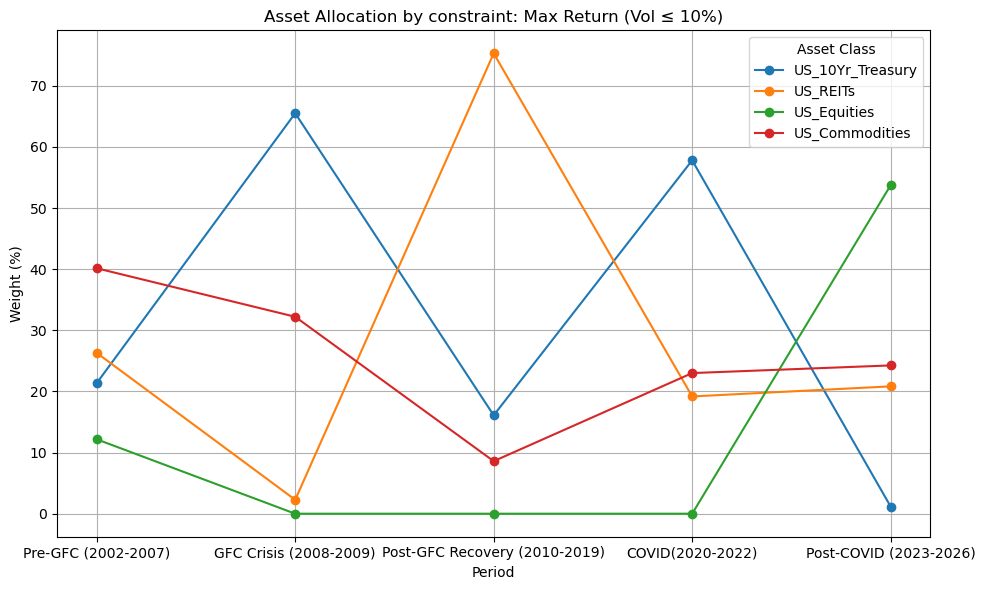

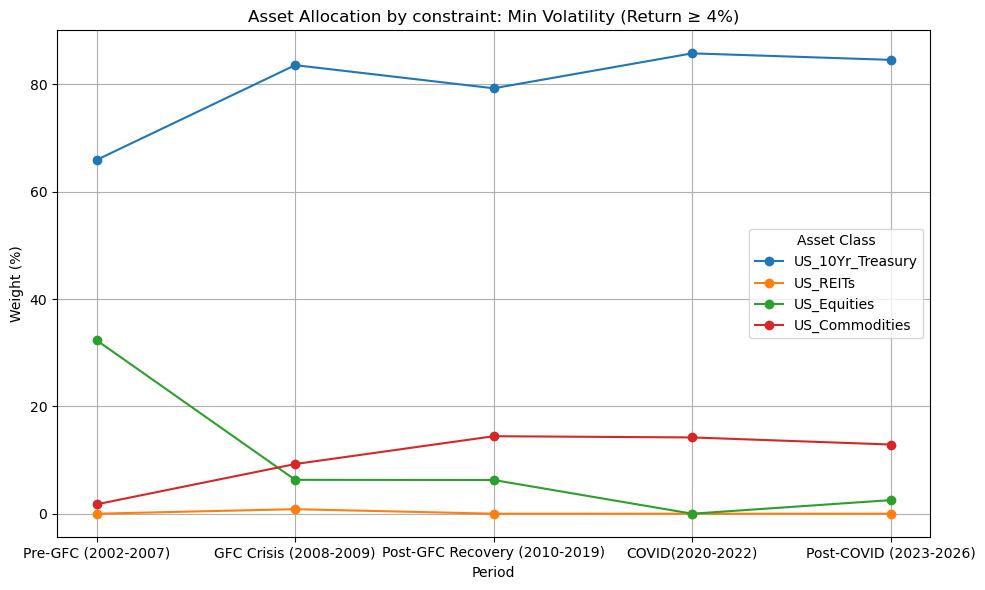

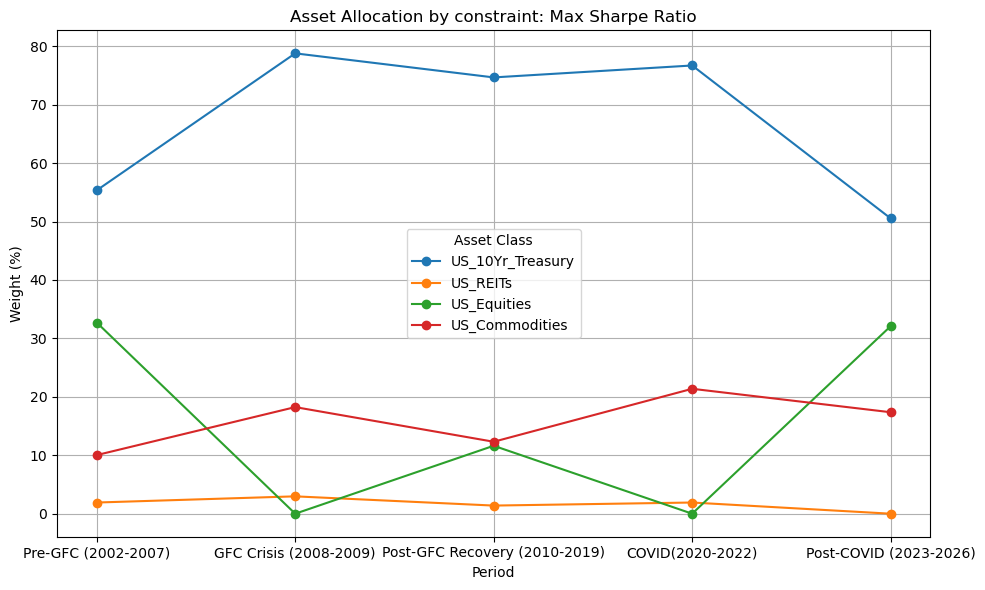

In [17]:
# re-run the optimization using ewma volatility at the end of each regime
end_date = pd.to_datetime([end for regime_name, (start, end) in regimes.items()])
cov_regimes = [entry['ewma_cov_annual'] for entry in ewma_series if entry['date'] in end_date]

portfolio_weights_by_regime = {
    'Max Return (Vol ≤ 10%)': {},
    'Min Volatility (Return ≥ 4%)': {},
    'Max Sharpe Ratio': {}
}

for i, cov_regime in enumerate(cov_regimes):
    name = list(regimes.keys())[i]
    day = end_date[i]
    update_returns = returns.loc[:day].mean().values * 12

    print(f'Optimization Results using EWMA covariance at the end of regime (Date: {day.date()}):\n')
    print_portfolio(update_returns, cov_regime, asset_names)
    
    w1, _, _, _ = run_opt('max_return', update_returns, cov_regime)
    w2, _, _, _ = run_opt('min_vol', update_returns, cov_regime)
    w3, _, _, _ = run_opt('max_sharpe', update_returns, cov_regime)
    
    portfolio_weights_by_regime['Max Return (Vol ≤ 10%)'][name] = w1 * 100
    portfolio_weights_by_regime['Min Volatility (Return ≥ 4%)'][name] = w2 * 100
    portfolio_weights_by_regime['Max Sharpe Ratio'][name] = w3 * 100

for strategy_name, weights_dict in portfolio_weights_by_regime.items():
    df = pd.DataFrame(weights_dict, index=asset_names).T
    plt.figure(figsize=(10, 6))
    for asset in df.columns:
        plt.plot(df.index, df[asset], marker='o', label=asset)
    plt.title(f"Asset Allocation by constraint: {strategy_name}")
    plt.ylabel('Weight (%)')
    plt.xlabel('Period')
    plt.legend(title='Asset Class')
    plt.grid(True)
    plt.tight_layout()
    plt.show() 


<span style="font-size:18px; color:Black;"> **Using the historical data, setup backtesting study for three risk-based optimal portfolios (equal weight, min vol, max diversification) for comparison and recommendation** </span>  

In [18]:
# diversification ratio function
def max_divsf(weights, covariance):
    port_var = portfolio_volatility(weights, covariance)**2
    weighted_vol = np.sum(weights * np.sqrt(np.diag(covariance)))
    return -weighted_vol / port_var  # negative for maximization

#backtesting function 
def backtest_portfolio(returns, window_size=36, rebalance_freq=3):
    num_assets = returns.shape[1]
    all_dates = returns.index
    rebalance_dates = all_dates[window_size::rebalance_freq]  # rebalance every 3 months, intitial day is index 36

    ewma_series = cal_ewma_series(returns, lam=0.94)
    ewma_dict = {entry['date']: entry['ewma_cov_annual'] for entry in ewma_series}

    portfolio_returns = pd.DataFrame(index=all_dates[window_size:],\
                                     columns=['Equal Weight', 'Min Volatility', 'Max Diversification'])
    
    weights_history ={
        'Equal Weight': pd.DataFrame(index=rebalance_dates, columns=returns.columns),
        'Min Volatility': pd.DataFrame(index=rebalance_dates, columns=returns.columns),
        'Max Diversification': pd.DataFrame(index=rebalance_dates, columns=returns.columns)
    }

    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(num_assets))

    current_weights = {
        'Equal Weight': np.array([1/num_assets] * num_assets),
        'Min Volatility': np.array([1/num_assets] * num_assets),
        'Max Diversification': np.array([1/num_assets] * num_assets)
    }

    for i, current_date in enumerate(all_dates[window_size:]):
        if current_date in rebalance_dates:
             # last return is for calculating porfolio returns, others are for weights
            window_returns = returns.loc[current_date-pd.DateOffset(months=window_size):current_date-pd.DateOffset(months=1)]
            
            ann_returns = window_returns.mean().values * 12
            ann_cov = ewma_dict[current_date-pd.DateOffset(months=1)]  # use ewma covariance at the end of the window

            # Equal Weight
            current_weights['Equal Weight'] = np.array([1/num_assets] * num_assets)

            # Min Volatility
            min_vol_result = minimize(
                fun = lambda x: portfolio_volatility(x, ann_cov),
                x0 = current_weights['Min Volatility'],
                method = 'SLSQP',
                bounds = bounds,
                constraints = constraints
            )
            current_weights['Min Volatility'] = min_vol_result.x
            # Max Diversification
            max_div_result = minimize(
                fun = lambda x: max_divsf(x, ann_cov),  
                x0 = current_weights['Max Diversification'],
                method = 'SLSQP',
                bounds = bounds,
                constraints = constraints
            )
            current_weights['Max Diversification'] = max_div_result.x

            for strategy in weights_history:
                weights_history[strategy].loc[current_date] = current_weights[strategy] * 100  # store weights in percentage

        current_month_returns = returns.loc[current_date]
        for strategy in portfolio_returns.columns:
            portfolio_returns.loc[current_date, strategy] = np.dot(current_weights[strategy], current_month_returns)
    
    return portfolio_returns, weights_history

In [19]:
# performance metrics functions
def cal_performance_metrics(returns):
    total_cum_return = (1 + returns).prod() - 1
    annualized_return = returns.mean() * 12
    annualized_volatility = returns.std() * np.sqrt(12)
    sharpe_ratio = annualized_return / annualized_volatility

    cum_return = (1 + returns).cumprod() - 1
    running_max = cum_return.cummax()
    drawdown = (cum_return - running_max)/(1+running_max)
    max_drawdown = drawdown.min()

    confidence_level = 0.95
    var_95 = np.percentile(returns, 100 * (1 - confidence_level))
    cvar_95 = returns[returns < var_95].mean()

    metrics = pd.DataFrame({
        'Total Cumulative Return': [total_cum_return],
        'Annualized Return': [annualized_return],
        'Annualized Volatility': [annualized_volatility],
        'Sharpe Ratio': [sharpe_ratio],
        'Max Drawdown': [max_drawdown],
        'VaR': [-var_95],
        'CVaR': [-cvar_95]
    })
    
    return metrics

In [20]:
portfolio_returns, weights_history = backtest_portfolio(returns)

#performance metrics for backtested portfolios
print("Performance Metrics for Backtested Portfolios:")
performance_metrics = []
for col in portfolio_returns.columns:
    performance_metrics.append(cal_performance_metrics(portfolio_returns[col]).T)

performance_metrics = pd.concat(performance_metrics, axis=1)
performance_metrics.columns = portfolio_returns.columns
print(performance_metrics.round(4))

Performance Metrics for Backtested Portfolios:
                         Equal Weight  Min Volatility  Max Diversification
Total Cumulative Return        2.4067          1.0716               1.1251
Annualized Return              0.0662          0.0366               0.0379
Annualized Volatility          0.1169          0.0543               0.0557
Sharpe Ratio                   0.5663          0.6750               0.6815
Max Drawdown                  -0.4274         -0.1842              -0.1784
VaR                            0.0486          0.0237               0.0247
CVaR                           0.0829          0.0349               0.0368


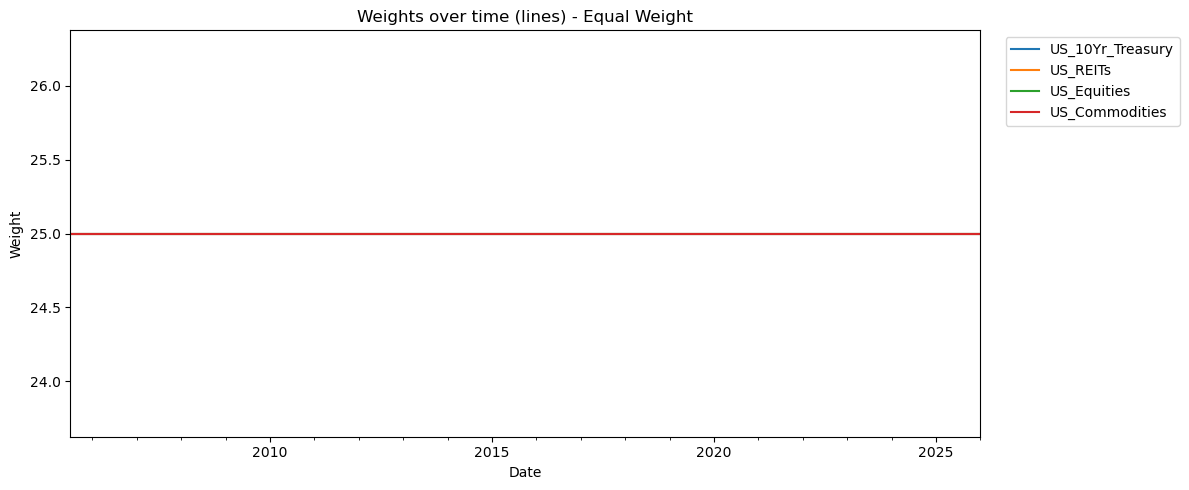

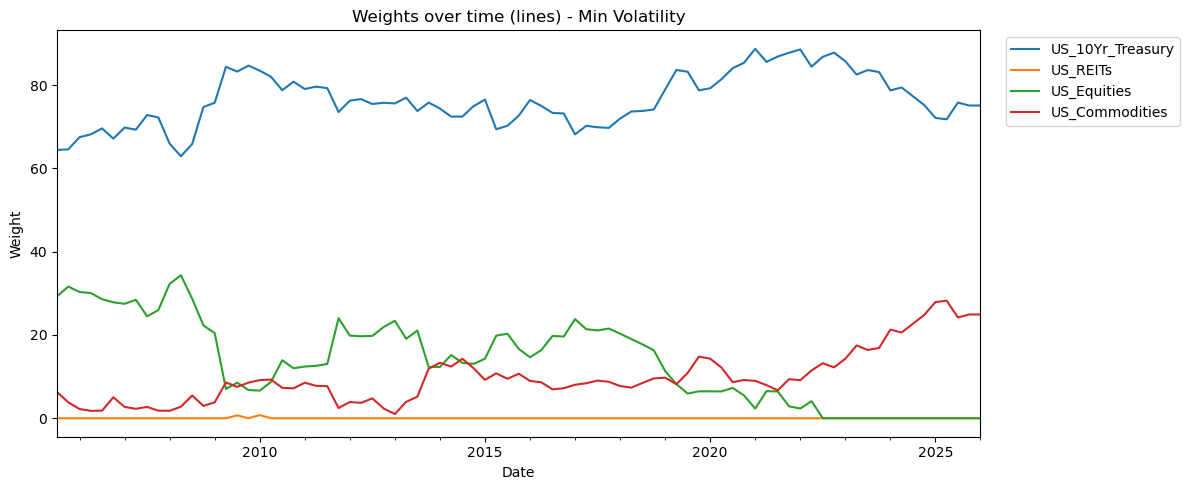

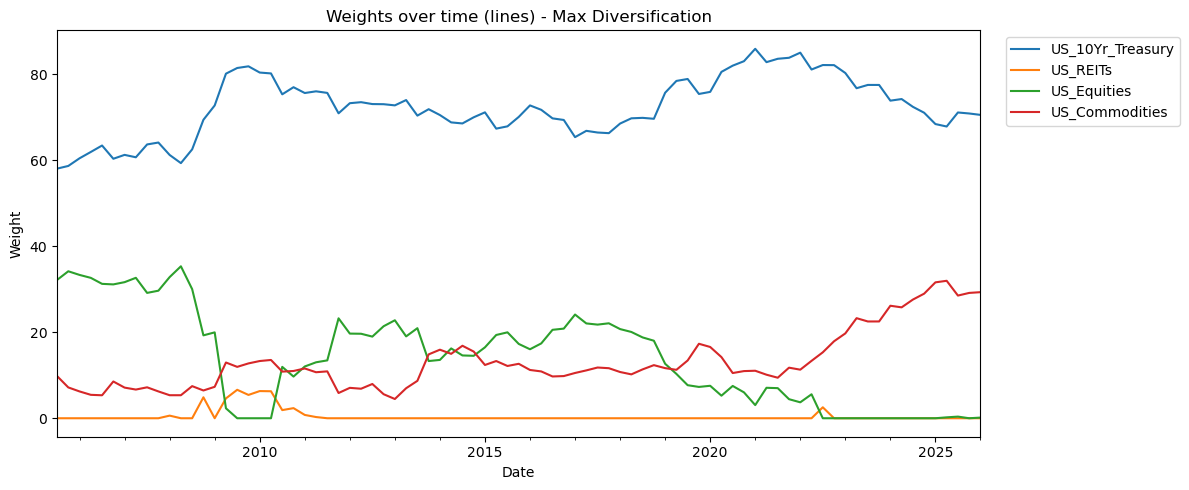

In [21]:
for name, w in weights_history.items():
    plt.figure(figsize=(12,5))
    w.plot(ax=plt.gca())
    plt.title(f'Weights over time (lines) - {name}')
    plt.ylabel('Weight')
    plt.xlabel('Date')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)\
               , labels=list(tickers.keys()))
    plt.tight_layout()
    plt.show()

In [22]:
print("\nPortfolio Recommendation Summary:")

best_cum_return = performance_metrics.T['Total Cumulative Return'].idxmax()
best_return = performance_metrics.T['Annualized Return'].idxmax()
lowest_vol = performance_metrics.T['Annualized Volatility'].idxmin()
best_sharpe = performance_metrics.T['Sharpe Ratio'].idxmax()
smallest_drawdown = performance_metrics.T['Max Drawdown'].idxmax()  # Max because drawdown is negat
lowest_VaR = performance_metrics.T['VaR'].idxmin()
lowest_CVaR = performance_metrics.T['CVaR'].idxmin()

print(f"Best overall cumulative return: {best_cum_return}")
print(f"Best Annualized return: {best_return}")
print(f"Lowest volatility: {lowest_vol}")
print(f"Best overall Sharpe ratio: {best_sharpe}")
print(f"Smallest maximum drawdown: {smallest_drawdown}")
print(f"Lowest VaR: {lowest_VaR}")
print(f"Lowest CVaR: {lowest_CVaR}")


Portfolio Recommendation Summary:
Best overall cumulative return: Equal Weight
Best Annualized return: Equal Weight
Lowest volatility: Min Volatility
Best overall Sharpe ratio: Max Diversification
Smallest maximum drawdown: Max Diversification
Lowest VaR: Min Volatility
Lowest CVaR: Min Volatility


<Figure size 1200x600 with 0 Axes>

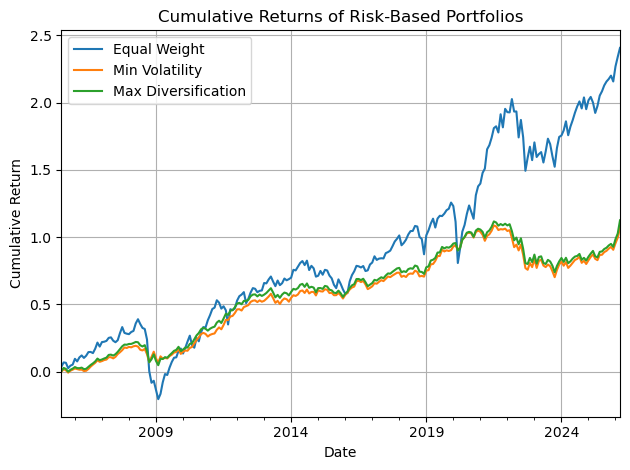

In [23]:
cumulative_returns = (1 + portfolio_returns).cumprod() - 1

plt.figure(figsize=(12, 6))
cumulative_returns.plot()
plt.title('Cumulative Returns of Risk-Based Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_returns.png')

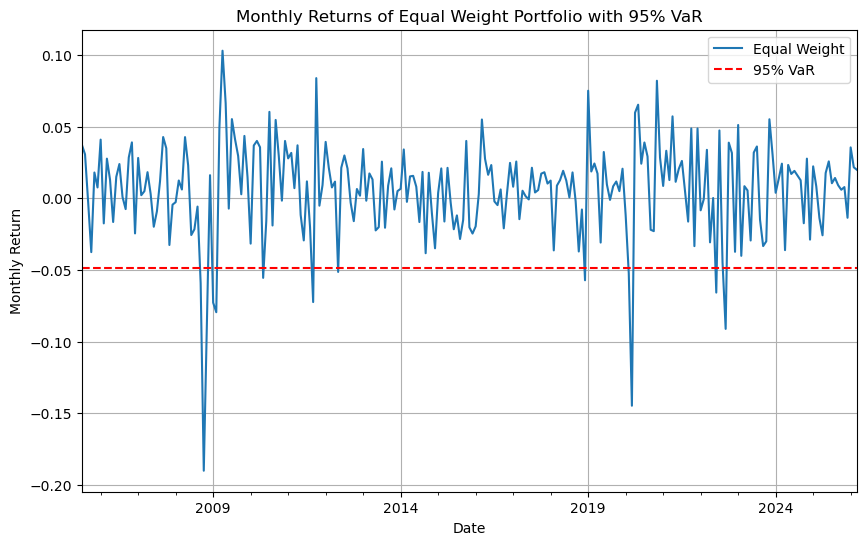

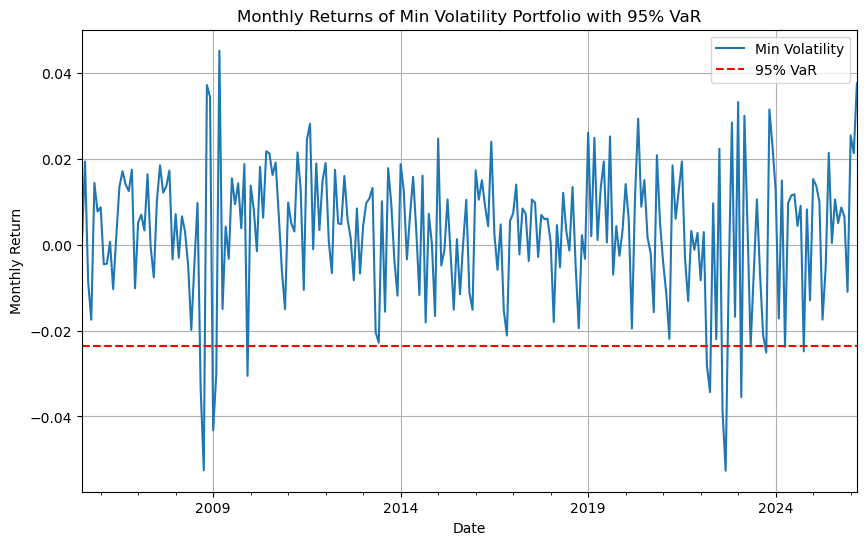

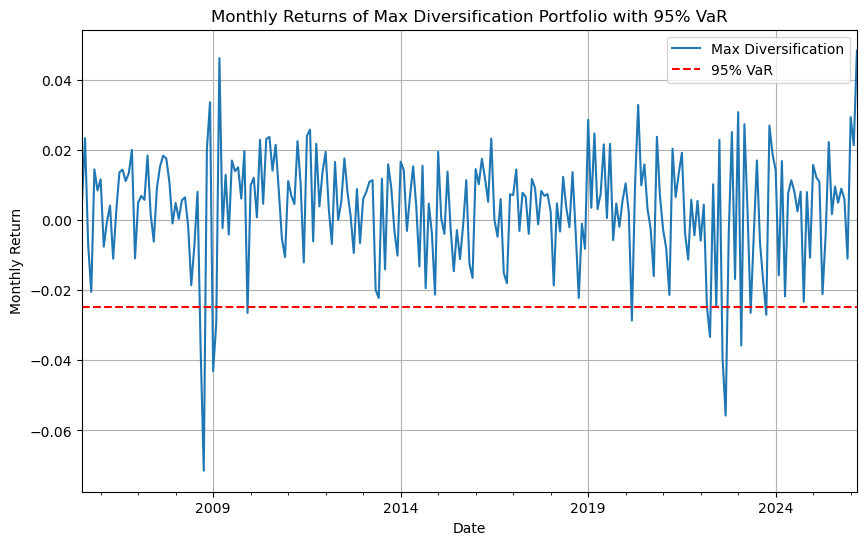

In [24]:
for portfolio in portfolio_returns.columns:
    plt.figure(figsize=(10, 6))
    portfolio_returns[portfolio].plot(label=portfolio)

    #Calculate and plot the 95% confidence VaR line
    var_95 = portfolio_returns[portfolio].quantile(0.05)  # 5th percentile for 95% VaR
    plt.axhline(y=var_95, color='red', linestyle='--', label='95% VaR')
    
    plt.title(f'Monthly Returns of {portfolio} Portfolio with 95% VaR')
    plt.xlabel('Date')
    plt.ylabel('Monthly Return')
    plt.legend()
    plt.grid(True)
    plt.show()